# 01_eda: Exploratory Data Analysis for Dental AI Pipeline

Comprehensive Exploratory Data Analysis across all dataset sources:
1. **Source Inventory**: Summary of raw and interim data sources.
2. **Class Balance**: Analysis of class distributions & imbalance ratio.
3. **Sample Image Grids**: Visual inspection per unified class.
4. **Resolution & Aspect Ratios**: Distribution of image shapes.
5. **Duplicate / Near-Duplicate Detection**: Perceptual hashing (imagehash).
6. **Color & Intensity Distributions**: Channel histograms (RGB).
7. **Bounding Box Overlays & Preprocessing**: YOLO detector label overlays and Albumentations augmentation pipeline.


In [1]:
from pathlib import Path

import albumentations as A
import cv2
import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Output figure directory
fig_dir = Path('../report/figures')
fig_dir.mkdir(parents=True, exist_ok=True)
print('Figure directory ready:', fig_dir.resolve())


Figure directory ready: C:\Users\user\Downloads\dental-model\report\figures


## Section 1: Source Inventory
Analyze image counts and structure across all available datasets in data/interim.


Source Inventory:
                  Source  Image Count
0         caries_spectra         2234
1     roboflow_detection         6188
2          plaque_diagno         5276
3  gingivitis_captioning            0


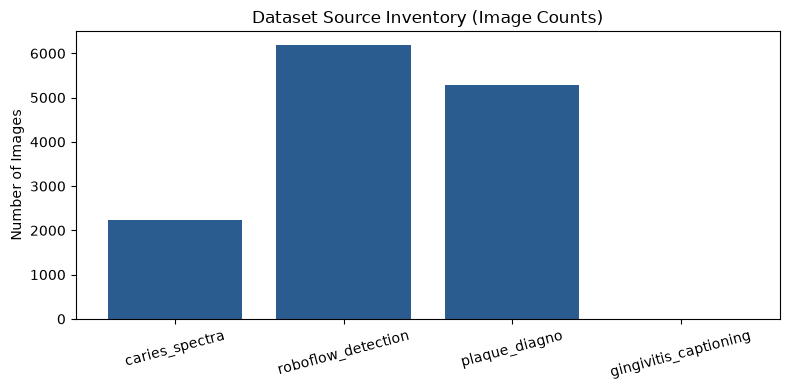

In [2]:
interim_dir = Path('../data/interim')
sources = ['caries_spectra', 'roboflow_detection', 'plaque_diagno', 'gingivitis_captioning']
valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

inventory = {}
for src in sources:
    src_path = interim_dir / src
    if src_path.exists():
        img_count = sum(1 for p in src_path.rglob('*') if p.suffix.lower() in valid_exts)
        inventory[src] = img_count
    else:
        inventory[src] = 0

df_inv = pd.DataFrame(list(inventory.items()), columns=['Source', 'Image Count'])
print('Source Inventory:')
print(df_inv)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_inv['Source'], df_inv['Image Count'], color='#2b5c8f')
ax.set_title('Dataset Source Inventory (Image Counts)')
ax.set_ylabel('Number of Images')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(fig_dir / '01_source_inventory.png', dpi=150)
plt.show()


## Section 2: Class Balance & Imbalance Ratio
Analyze the distribution across the unified classification dataset (data/processed/classifier/labels.csv).


                                          image_path  \
0  C:\Users\user\Downloads\dental-model\data\inte...   
1  C:\Users\user\Downloads\dental-model\data\inte...   
2  C:\Users\user\Downloads\dental-model\data\inte...   
3  C:\Users\user\Downloads\dental-model\data\inte...   
4  C:\Users\user\Downloads\dental-model\data\inte...   

                                       relative_path         label  \
0  interim/caries_spectra/Caries_Dataset/EarlySta...  caries_early   
1  interim/caries_spectra/Caries_Dataset/EarlySta...  caries_early   
2  interim/caries_spectra/Caries_Dataset/EarlySta...  caries_early   
3  interim/caries_spectra/Caries_Dataset/EarlySta...  caries_early   
4  interim/caries_spectra/Caries_Dataset/EarlySta...  caries_early   

           source                raw_label  split  
0  caries_spectra  EarlyStageEnamel_Caries  train  
1  caries_spectra  EarlyStageEnamel_Caries  train  
2  caries_spectra  EarlyStageEnamel_Caries  train  
3  caries_spectra  EarlyStageEname

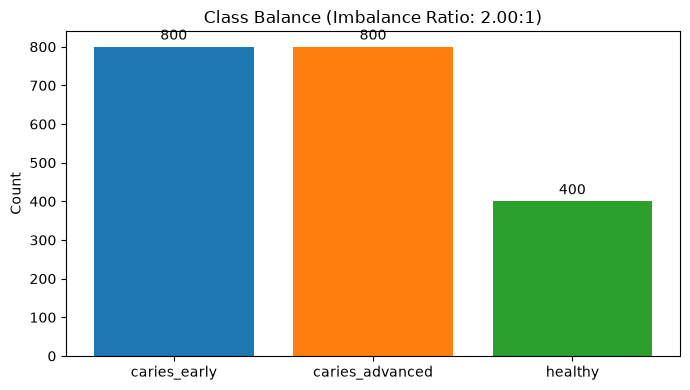

In [3]:
labels_csv = Path('../data/processed/classifier/labels.csv')
df_labels = pd.read_csv(labels_csv)
print(df_labels.head())

class_counts = df_labels['label'].value_counts()
print('\nClass counts:\n', class_counts)

max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count
print(f'\nClass Imbalance Ratio (Majority / Minority): {imbalance_ratio:.2f} : 1')
print(f'Majority Class: {class_counts.idxmax()} ({max_count})')
print(f'Minority Class: {class_counts.idxmin()} ({min_count})')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_title(f'Class Balance (Imbalance Ratio: {imbalance_ratio:.2f}:1)')
ax.set_ylabel('Count')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(fig_dir / '02_class_balance.png', dpi=150)
plt.show()


## Section 3: Sample Image Grids
Visual examination of samples from each unified class.


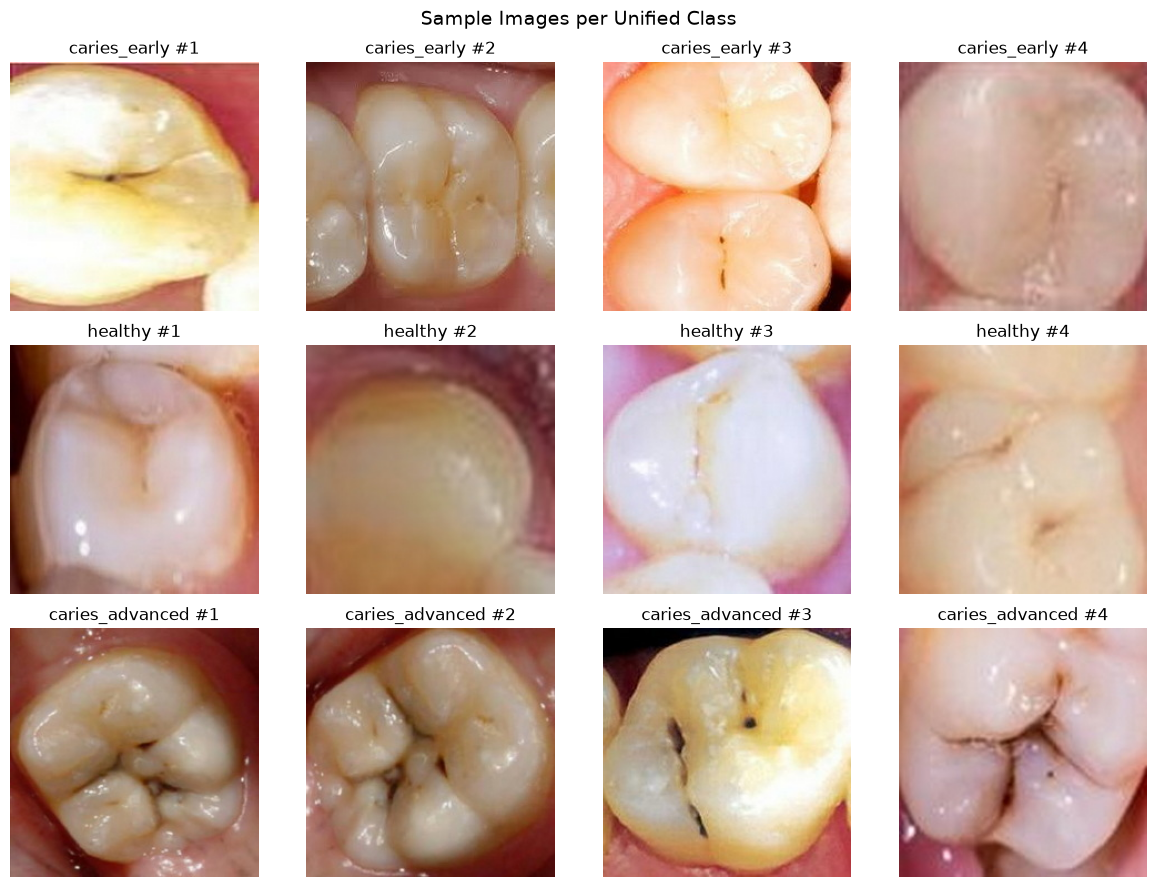

In [4]:
classes = df_labels['label'].unique()
fig, axes = plt.subplots(len(classes), 4, figsize=(12, 3 * len(classes)))

for row_idx, cls_name in enumerate(classes):
    cls_samples = (
        df_labels[df_labels['label'] == cls_name]['image_path']
        .sample(4, random_state=42)
        .tolist()
    )
    for col_idx, img_p in enumerate(cls_samples):
        ax = axes[row_idx, col_idx] if len(classes) > 1 else axes[col_idx]
        img = cv2.imread(img_p)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
        ax.set_title(f'{cls_name} #{col_idx+1}')
        ax.axis('off')

plt.suptitle('Sample Images per Unified Class', fontsize=14)
plt.tight_layout()
plt.savefig(fig_dir / '03_sample_grids.png', dpi=150)
plt.show()


## Section 4: Image Dimensions & Aspect Ratios
Distribution of image heights, widths, and aspect ratios.


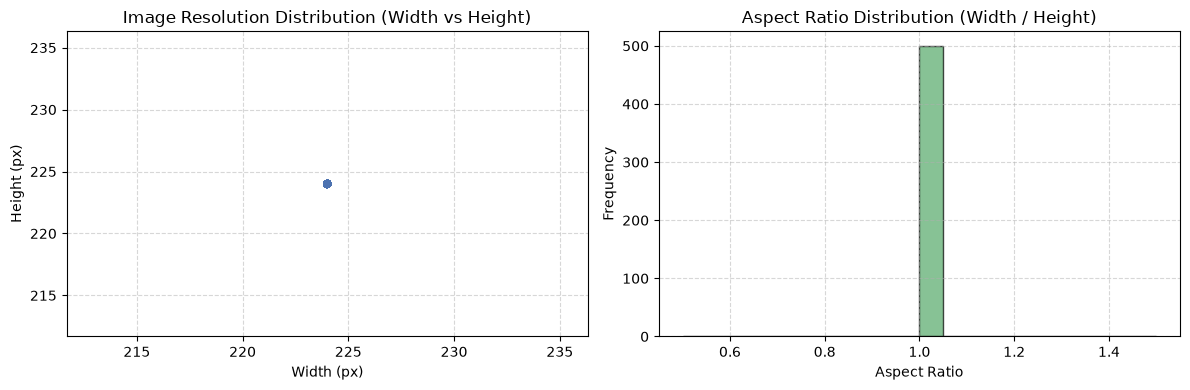

In [5]:
sample_df = df_labels.sample(min(500, len(df_labels)), random_state=42)
heights = []
widths = []
aspect_ratios = []

for p in sample_df['image_path']:
    img = Image.open(p)
    w, h = img.size
    widths.append(w)
    heights.append(h)
    aspect_ratios.append(w / h)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(widths, heights, alpha=0.6, color='#4c72b0', edgecolors='none')
ax1.set_title('Image Resolution Distribution (Width vs Height)')
ax1.set_xlabel('Width (px)')
ax1.set_ylabel('Height (px)')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.hist(aspect_ratios, bins=20, color='#55a868', edgecolor='black', alpha=0.7)
ax2.set_title('Aspect Ratio Distribution (Width / Height)')
ax2.set_xlabel('Aspect Ratio')
ax2.set_ylabel('Frequency')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(fig_dir / '04_image_sizes.png', dpi=150)
plt.show()


## Section 5: Duplicate / Near-Duplicate Detection
Using perceptual hashing (imagehash.average_hash) to detect exact and near-duplicates (Hamming distance <= 2).


Total Images Scanned: 2000
Total Near-Duplicate Pairs Detected (Hamming <= 2): 831


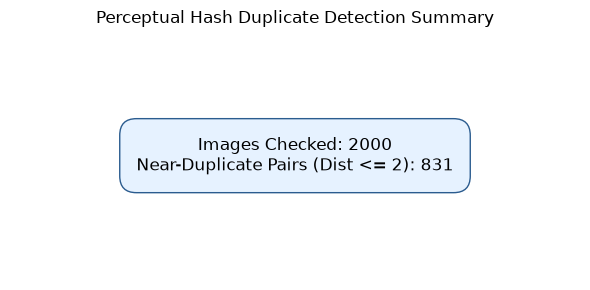

In [6]:
hashes = {}
near_duplicates = []
threshold = 2

sample_files = df_labels['image_path'].tolist()
for p in sample_files:
    try:
        h = imagehash.average_hash(Image.open(p))
        hashes[p] = h
    except Exception:
        pass

hash_list = list(hashes.items())
for i in range(len(hash_list)):
    p1, h1 = hash_list[i]
    for j in range(i + 1, len(hash_list)):
        p2, h2 = hash_list[j]
        diff = h1 - h2
        if diff <= threshold:
            near_duplicates.append((p1, p2, diff))

print(f'Total Images Scanned: {len(hashes)}')
print(f'Total Near-Duplicate Pairs Detected (Hamming <= {threshold}): {len(near_duplicates)}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.text(0.5, 0.5, (
        f'Images Checked: {len(hashes)}\n'
        f'Near-Duplicate Pairs (Dist <= {threshold}): {len(near_duplicates)}'
    ),
        fontsize=12, ha='center', va='center', bbox=dict(
            boxstyle='round,pad=1', facecolor='#e6f2ff', edgecolor='#2b5c8f'
        )
    )
ax.axis('off')
ax.set_title('Perceptual Hash Duplicate Detection Summary')
plt.tight_layout()
plt.savefig(fig_dir / '05_duplicates.png', dpi=150)
plt.show()


## Section 6: Color & Pixel Intensity Distribution
RGB channel histograms across representative samples.


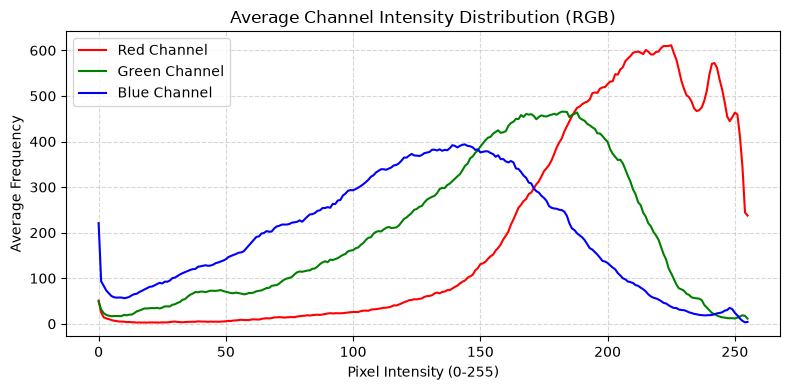

In [7]:
sample_images = df_labels['image_path'].sample(min(100, len(df_labels)), random_state=42).tolist()
r_hist, g_hist, b_hist = np.zeros(256), np.zeros(256), np.zeros(256)

for p in sample_images:
    img = cv2.imread(p)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        r_hist += cv2.calcHist([img_rgb], [0], None, [256], [0, 256]).flatten()
        g_hist += cv2.calcHist([img_rgb], [1], None, [256], [0, 256]).flatten()
        b_hist += cv2.calcHist([img_rgb], [2], None, [256], [0, 256]).flatten()

r_hist /= len(sample_images)
g_hist /= len(sample_images)
b_hist /= len(sample_images)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_hist, color='red', label='Red Channel', linewidth=1.5)
ax.plot(g_hist, color='green', label='Green Channel', linewidth=1.5)
ax.plot(b_hist, color='blue', label='Blue Channel', linewidth=1.5)
ax.set_title('Average Channel Intensity Distribution (RGB)')
ax.set_xlabel('Pixel Intensity (0-255)')
ax.set_ylabel('Average Frequency')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(fig_dir / '06_color_distribution.png', dpi=150)
plt.show()


## Section 7: Bounding Box Overlays & Preprocessing Verification
Visualizing detector ground-truth bounding boxes (healthy, plaque, caries) and verifying Albumentations data augmentation.


Found 4881 detector training images


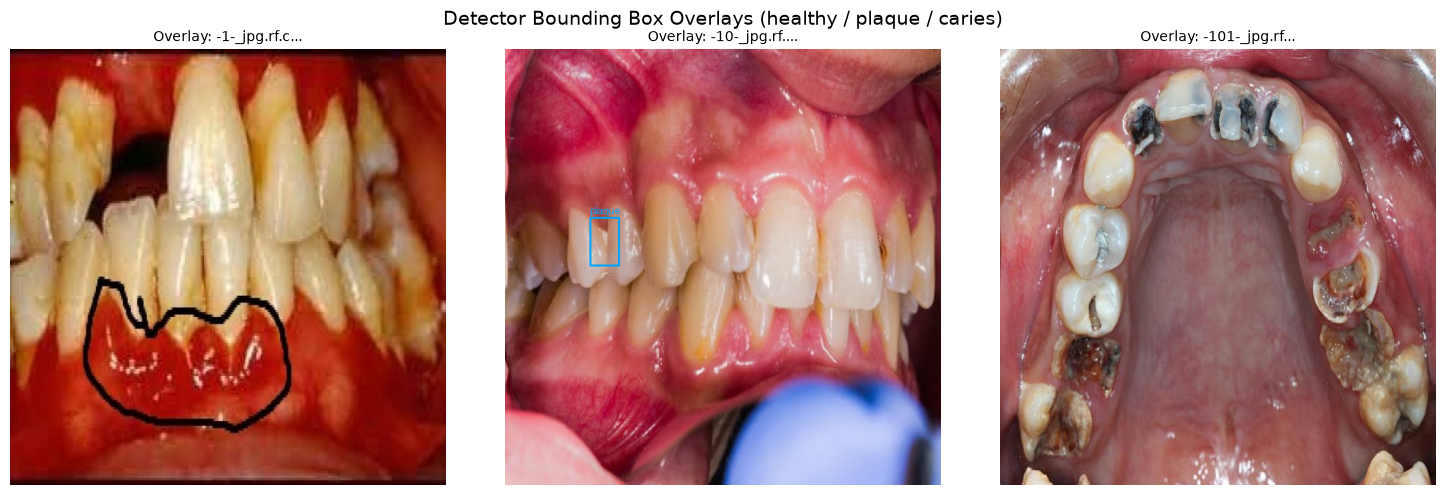

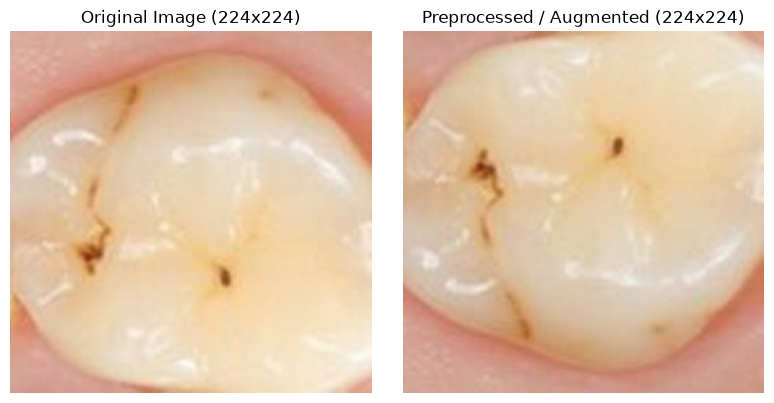

In [8]:
# 1. Bounding Box Overlays from data/processed/detector/
detector_dir = Path('../data/processed/detector/train')
img_files = list((detector_dir / 'images').glob('*.jpg'))
print(f'Found {len(img_files)} detector training images')

sample_files = img_files[:3]
target_class_names = {0: 'healthy', 1: 'plaque', 2: 'caries'}
class_colors = {0: (0, 255, 0), 1: (255, 165, 0), 2: (255, 0, 0)}

fig, axes = plt.subplots(1, max(3, len(sample_files)), figsize=(15, 5))
for idx, img_p in enumerate(sample_files):
    ax = axes[idx] if len(sample_files) > 1 else axes
    img = cv2.imread(str(img_p))
    h_img, w_img, _ = img.shape
    lbl_p = detector_dir / 'labels' / (img_p.stem + '.txt')

    if lbl_p.exists():
        with open(lbl_p) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    xc, yc, w, h = map(float, parts[1:5])
                    x1 = int((xc - w / 2) * w_img)
                    y1 = int((yc - h / 2) * h_img)
                    x2 = int((xc + w / 2) * w_img)
                    y2 = int((yc + h / 2) * h_img)
                    name = target_class_names.get(cls_id, f'cls_{cls_id}')
                    color = class_colors.get(cls_id, (0, 255, 255))
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(
                        img, name, (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1
                    )

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(f'Overlay: {img_p.stem[:12]}...', fontsize=10)
    ax.axis('off')

plt.suptitle('Detector Bounding Box Overlays (healthy / plaque / caries)', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Before / After Preprocessing (Albumentations 1.3.1 compatible)
aug = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
])

sample_img_p = df_labels['image_path'].iloc[0]
raw_img = cv2.imread(sample_img_p)
raw_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
aug_img = aug(image=raw_rgb)['image']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(raw_rgb)
ax1.set_title(f'Original Image ({raw_rgb.shape[1]}x{raw_rgb.shape[0]})')
ax1.axis('off')

ax2.imshow(aug_img)
ax2.set_title(f'Preprocessed / Augmented ({aug_img.shape[1]}x{aug_img.shape[0]})')
ax2.axis('off')

plt.tight_layout()
plt.savefig(fig_dir / '07_before_after_preprocessing.png', dpi=150)
plt.show()
